In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
import os

os.makedirs("graphs", exist_ok=True)

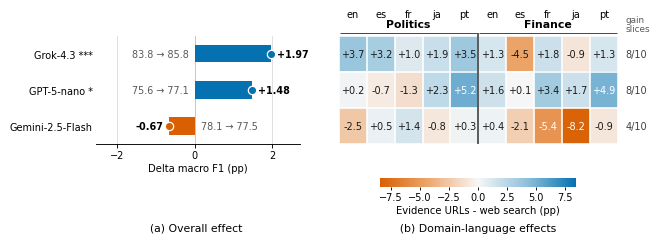

In [2]:
# ------------------------------------------------------------
# Input: scores.csv only
# ------------------------------------------------------------

scores = pd.read_csv("../experiments/scores.csv").drop(columns=["Unnamed: 0"], errors="ignore")
scores = scores.set_index("method")


# Display label, model key in scores.csv
MODELS = [
    ("Grok-4.3 ***", "grok-4.3"),
    ("GPT-5-nano *", "gpt-5-nano"),
    ("Gemini-2.5-Flash", "gemini-2.5-flash"),
]

LANGS = ["en", "es", "fr", "ja", "pt"]
SLICE_COLS = [f"politics_{l}" for l in LANGS] + [f"finance_{l}" for l in LANGS]


# ------------------------------------------------------------
# Build paired data:
# delta = Evidence URLs - Web search, in percentage points
# ------------------------------------------------------------

overall_rows = []
heat_rows = []

for label, key in MODELS:
    web_key = f"web_search_{key}_True_True"
    url_key = f"web_search_URL_{key}_True_True"

    if web_key not in scores.index or url_key not in scores.index:
        raise KeyError(f"Missing rows for {key}: {web_key}, {url_key}")

    web = scores.loc[web_key]
    url = scores.loc[url_key]

    delta = (url[SLICE_COLS] - web[SLICE_COLS]).astype(float).to_numpy()

    overall_rows.append(
        {
            "model": label,
            "web": float(web["overall"]),
            "url": float(url["overall"]),
            "delta": float(url["overall"] - web["overall"]),
        }
    )
    heat_rows.append(delta)

overall = pd.DataFrame(overall_rows)
heat = np.vstack(heat_rows)


# ------------------------------------------------------------
# Typography: one compact scale for paper figures
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 7.2,
        "axes.linewidth": 0.65,
        "xtick.major.width": 0.65,
        "ytick.major.width": 0.65,
        "xtick.major.size": 2.7,
        "ytick.major.size": 0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

FS_PANEL = 8.4
FS_TITLE = 7.8
FS_LABEL = 7.2
FS_TICK = 7.0
FS_TEXT = 6.9
FS_CELL = 7.0
FS_SMALL = 6.4

blue = "#0571b0"
orange = "#d95f02"

cmap = LinearSegmentedColormap.from_list(
    "evidence_delta",
    [orange, "#eda86f", "#f7f7f7", "#8ec0da", blue],
    N=256,
)
norm = TwoSlopeNorm(vmin=-8.5, vcenter=0.0, vmax=8.5)


# ------------------------------------------------------------
# Manual layout.
# Both panels share the same row axis position, so model rows
# align exactly across panels.
# ------------------------------------------------------------

fig = plt.figure(figsize=(7.15, 2.52))

# [left, bottom, width, height] in figure coordinates
ax_a = fig.add_axes([0.105, 0.315, 0.285, 0.43])
# ax_h = fig.add_axes([0.535, 0.315, 0.390, 0.43])
ax_h = fig.add_axes([0.445, 0.315, 0.390, 0.43])
# cax = fig.add_axes([0.610, 0.145, 0.275, 0.035])
cax = fig.add_axes([0.502, 0.145, 0.275, 0.035])

# Panel titles on one baseline
space = " " * 45
fig.text(
    0.465,
    -0.03,
    f"(a) Overall effect{space}(b) Domain-language effects",
    fontsize=FS_TITLE,
    ha="center",
    va="baseline",
)


# ------------------------------------------------------------
# Panel a: overall delta bar chart
# ------------------------------------------------------------

y = np.arange(len(overall))

for i, row in overall.iterrows():
    d = row["delta"]
    color = blue if d >= 0 else orange

    ax_a.barh(
        i,
        abs(d),
        left=min(0, d),
        height=0.48,
        color=color,
        edgecolor="none",
        zorder=2,
    )

    ax_a.scatter(
        d,
        i,
        s=36,
        color=color,
        edgecolor="white",
        linewidth=0.9,
        zorder=4,
    )

    if d >= 0:
        ax_a.text(
            -0.15,
            i,
            f"{row['web']:.1f} → {row['url']:.1f}",
            ha="right",
            va="center",
            fontsize=FS_TEXT,
            color="0.35",
        )
        ax_a.text(
            d + 0.14,
            i,
            f"{d:+.2f}",
            ha="left",
            va="center",
            fontsize=FS_TEXT,
            fontweight="bold",
            color="black",
        )
    else:
        ax_a.text(
            d - 0.14,
            i,
            f"{d:+.2f}",
            ha="right",
            va="center",
            fontsize=FS_TEXT,
            fontweight="bold",
            color="black",
        )
        ax_a.text(
            0.15,
            i,
            f"{row['web']:.1f} → {row['url']:.1f}",
            ha="left",
            va="center",
            fontsize=FS_TEXT,
            color="0.35",
        )

ax_a.axvline(0, color="0.40", lw=0.70, zorder=1)

ax_a.set_xlim(-2.55, 2.70)
ax_a.set_ylim(len(MODELS) - 0.5, -0.5)

ax_a.set_xticks([-2, 0, 2])
ax_a.set_yticks(y)
ax_a.set_yticklabels(overall["model"], fontsize=FS_TICK)

ax_a.set_xlabel("Delta macro F1 (pp)", fontsize=FS_LABEL, labelpad=2.5)

ax_a.grid(axis="x", color="0.86", lw=0.6, zorder=0)
ax_a.tick_params(axis="x", labelsize=FS_TICK, pad=1.5)
ax_a.tick_params(axis="y", pad=2)

ax_a.spines[["top", "right", "left"]].set_visible(False)


# ------------------------------------------------------------
# Panel b: domain-language heatmap
# ------------------------------------------------------------

im = ax_h.imshow(heat, cmap=cmap, norm=norm, aspect="auto")

ax_h.set_xlim(-0.5, 9.5)
ax_h.set_ylim(len(MODELS) - 0.5, -0.5)

# Cell borders
ax_h.set_xticks(np.arange(-0.5, 10, 1), minor=True)
ax_h.set_yticks(np.arange(-0.5, len(MODELS), 1), minor=True)
ax_h.grid(which="minor", color="white", linewidth=1.15)
ax_h.tick_params(which="minor", bottom=False, left=False)

ax_h.set_xticks([])
ax_h.set_yticks(y)
ax_h.set_yticklabels([])
ax_h.tick_params(axis="y", pad=2)

ax_h.spines[:].set_visible(False)

# Top language labels
for c, lab in enumerate(LANGS + LANGS):
    ax_h.text(
        c,
        -1.10,
        lab,
        ha="center",
        va="center",
        fontsize=FS_TICK,
        clip_on=False,
    )

# Domain headers
ax_h.text(
    2.0,
    -0.82,
    "Politics",
    ha="center",
    va="center",
    fontsize=FS_TITLE,
    fontweight="bold",
    clip_on=False,
)

ax_h.text(
    7.0,
    -0.82,
    "Finance",
    ha="center",
    va="center",
    fontsize=FS_TITLE,
    fontweight="bold",
    clip_on=False,
)

# Header rules.
# Politics covers columns 0--4.
# Finance covers columns 5--9.
# The small gap around x=4.5 keeps the vertical divider visually clean.
ax_h.hlines(-0.58, -0.47, 4.47, color="0.22", lw=0.65, clip_on=False)
ax_h.hlines(-0.58, 4.53, 9.47, color="0.22", lw=0.65, clip_on=False)

# Vertical separator between Politics and Finance.
# Start at -0.58 so it connects cleanly to the header rule.
ax_h.vlines(
    4.5,
    -0.58,
    len(MODELS) - 0.5,
    color="0.22",
    lw=1.15,
    clip_on=False,
)

# Cell annotations
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        val = heat[r, c]
        text_color = "white" if abs(val) >= 4.5 else "0.10"

        ax_h.text(
            c,
            r,
            f"{val:+.1f}",
            ha="center",
            va="center",
            fontsize=FS_CELL,
            color=text_color,
        )

# Gain-slice labels
ax_h.text(
    9.78,
    -0.82,
    "gain\nslices",
    ha="left",
    va="center",
    fontsize=FS_SMALL,
    color="0.35",
    linespacing=0.90,
    clip_on=False,
)

for r in range(heat.shape[0]):
    ax_h.text(
        9.78,
        r,
        f"{int((heat[r] > 0).sum())}/10",
        ha="left",
        va="center",
        fontsize=FS_TICK,
        color="0.25",
        clip_on=False,
    )

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    cax=cax,
    orientation="horizontal",
)
cbar.set_label("Evidence URLs - web search (pp)", fontsize=FS_LABEL, labelpad=2)
cbar.set_ticks([-7.5, -5, -2.5, 0, 2.5, 5, 7.5])
cbar.ax.tick_params(labelsize=FS_TICK, length=2.0, pad=1.5)
cbar.outline.set_visible(False)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig.savefig(
    "graphs/cf_evidence_guided_websearch_comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()